<a href="https://colab.research.google.com/github/yawarabbasmalik/Deep-Learning-Approach-for-Text-Processing-/blob/main/Deep_Learning_Approach_for_Text_Processing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Exploration and Preprocessing

### a. Importing Dataset

In [ ]:
import pandas as pd

# Try reading the datasets with 'ISO-8859-1' encoding
df1 = pd.read_csv('/content/Legal_Sentences_For_Training_With_BERT.csv', encoding='ISO-8859-1')
df2 = pd.read_csv('/content/Testing_Set_Legal_Sentences.csv', encoding='ISO-8859-1')

# Merge the two datasets
df = pd.concat([df1, df2], ignore_index=True)
df.head()


,ID,Phrase,Sentiment,sentence,label
0,1,Getting nowhere with surplusage,-1.0,NaN,NaN
1,2,But the Court nowhere suggested that it would ...,-1.0,NaN,NaN
2,3,Petitioners objection to shaving his beard cla...,-1.0,NaN,NaN
3,4,That result clashes with everything else,-1.0,NaN,NaN
4,5,the tolerable duration of police inquiries in ...,0.0,NaN,NaN


The datasets have been successfully loaded and merged into a single dataframe. The merged dataframe contains the following columns:

- ID: An identifier for each entry.
- Phrase: The text of the legal sentence or review.
- Sentiment: Sentiment scores for the sentences from the training dataset (with values such as -1, 0, and 1).
- sentence: The text from the testing dataset.
- label: Sentiment scores for the sentences from the testing dataset.

It appears that the training and testing datasets have slightly different column names for similar data, which is why we see some columns with NaN values after merging.

### b. Initial Data Exploration

In [ ]:
# Initial data exploration

# Check the shape of the merged dataframe
shape = df.shape

# Check for missing values
missing_values = df.isnull().sum()

# Get basic statistics for numeric columns
basic_stats = df.describe()

shape, missing_values, basic_stats


((1076, 5),
 ID             0
 Phrase       500
 Sentiment    500
 sentence     576
 label        576
 dtype: int64,
                 ID   Sentiment       label
 count  1076.000000  576.000000  500.000000
 mean    270.842007   -0.190972    0.820000
 std     157.681820    0.867774    0.795529
 min       1.000000   -1.000000    0.000000
 25%     135.000000   -1.000000    0.000000
 50%     269.500000    0.000000    1.000000
 75%     404.000000    1.000000    1.000000
 max     576.000000    1.000000    2.000000)

Here are the insights from the initial data exploration:

**Shape of the Dataframe:**

The merged dataframe has 1076 rows and 5 columns.

**Missing Values:**

Phrase: 500 missing values.y

Sentiment: 500 missing values.

sentence: 576 missing values.

label: 576 missing values.

These missing values are expected because when we merged the two datasets, the columns that were unique to each dataset would naturally have missing values in the merged dataframe.

**Basic Statistics for Numeric Columns:**

Sentiment (from the training dataset):

Count: 576 values (out of 1076).

Mean: Approximately -0.19.

Minimum value: -1.

Maximum value: 1.

25% of the values are -1, 50% (median) are 0, and 75% of the values are 1.

label (from the testing dataset):

Count: 500 values (out of 1076).

Mean: Approximately 0.82.

Minimum value: 0.

Maximum value: 2.

25% of the values are 0, 50% (median) are 1, and 75% of the values are 1.

From the basic statistics, we can infer that the sentiments in the training dataset (Sentiment column) range from -1 to 1, with -1 possibly indicating negative sentiment, 0 indicating neutral, and 1 indicating positive. In the testing dataset (label column), the sentiment labels range from 0 to 2, which might correspond to negative, neutral, and positive sentiments, respectively.

### Dealing with Unrequired Columns & Missing Values

In [ ]:
# Drop the 'ID' column as it's not required for our analysis
df.drop(columns='ID', inplace=True)

# Merge 'Phrase' and 'sentence' columns into a single column, as they both represent text data
df['Text'] = df['Phrase'].fillna('') + df['sentence'].fillna('')

# Drop the original 'Phrase' and 'sentence' columns
df.drop(columns=['Phrase', 'sentence'], inplace=True)

# Merge 'Sentiment' and 'label' columns into a single column, as they both represent sentiment labels
# We will prioritize non-NaN values in the 'Sentiment' column
df['Sentiment_Label'] = df['Sentiment'].combine_first(df['label'])

# Drop the original 'Sentiment' and 'label' columns
df.drop(columns=['Sentiment', 'label'], inplace=True)

# Drop rows with missing sentiment labels
df.dropna(subset=['Sentiment_Label'], inplace=True)

df.head()


,Text,Sentiment_Label
0,Getting nowhere with surplusage,-1.0
1,But the Court nowhere suggested that it would ...,-1.0
2,Petitioners objection to shaving his beard cla...,-1.0
3,That result clashes with everything else,-1.0
4,the tolerable duration of police inquiries in ...,0.0


Removed the 'ID' column as it's not necessary for our analysis.

Merged the 'Phrase' and 'sentence' columns into a single 'Text' column, which contains the text data.

Merged the 'Sentiment' and 'label' columns into a single 'Sentiment_Label' column, which contains the sentiment labels.

Dropped rows with missing sentiment labels.

Now, our dataframe consists of two columns:

Text: Contains the text of the legal sentences or reviews.

Sentiment_Label: Contains the sentiment labels for each sentence or review.

### c. Text Data Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

# Downloading stopwords and wordnet data for preprocessing
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Initialize lemmatizer and define stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]

    # Return the cleaned and tokenized text
    return ' '.join(tokens)

# Apply preprocessing to the 'Text' column
df['Processed_Text'] = df['Text'].apply(preprocess_text)
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,Text,Sentiment_Label,Processed_Text
0,Getting nowhere with surplusage,-1.0,getting nowhere surplusage
1,But the Court nowhere suggested that it would ...,-1.0,court nowhere suggested would narrow bivens ex...
2,Petitioners objection to shaving his beard cla...,-1.0,petitioner objection shaving beard clash arkan...
3,That result clashes with everything else,-1.0,result clash everything else
4,the tolerable duration of police inquiries in ...,0.0,tolerable duration police inquiry trafficstop ...


**Lowercasing:** Convert all text to lowercase to ensure uniformity.
**Removing Punctuation:** Punctuation might not be useful for certain text analysis tasks.
**Tokenization:** Splitting text into individual words or tokens.
**Removing Stopwords:** Stopwords are common words (e.g., "and", "the", "is") that might not contain significant information for analysis.
**Stemming/Lemmatization:** Reducing words to their root/base form. Lemmatization is a more advanced form of this process, taking into account the morphological analysis of the words.

The dataframe now contains a Processed_Text column, which contains the preprocessed version of the text from the Text column.

## 2. Semantic Analysis

### a. Keyword Extraction Using TF-IDF

TF-IDF is a statistical method that evaluates the importance of a word in a document relative to a collection of documents (corpus). Words that appear frequently in a document but not in many documents throughout the corpus will have a high TF-IDF score, indicating their significance.

Steps involved:

1. Use the TfidfVectorizer from the sklearn.feature_extraction.text library to transform our text data.
2. Extract keywords based on the TF-IDF scores.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_df=0.85, max_features=10, ngram_range=(1,2))

# Fit and transform the preprocessed text to generate TF-IDF features
tfidf_matrix = vectorizer.fit_transform(df['Processed_Text'])

# Extract the top keywords based on TF-IDF scores
feature_names = vectorizer.get_feature_names_out()

# Display the top keywords
feature_names


array(['case', 'could', 'court', 'defendant', 'evidence', 'law',
       'sentence', 'state', 'trial', 'would'], dtype=object)

These keywords provide insights into the main topics and themes discussed in the reviews. Words like "court," "case," "trial," and "defendant" indicate the legal context of the dataset.



### b. Frequently Occurring Keywords

Given the top keywords we extracted using TF-IDF, we can dive deeper into their context by examining how they appear in the dataset. One way to do this is by visualizing the distribution of these keywords using a word cloud. The word cloud will give us a visual representation of the prominence of each keyword.

Let's create a word cloud for our top keywords.

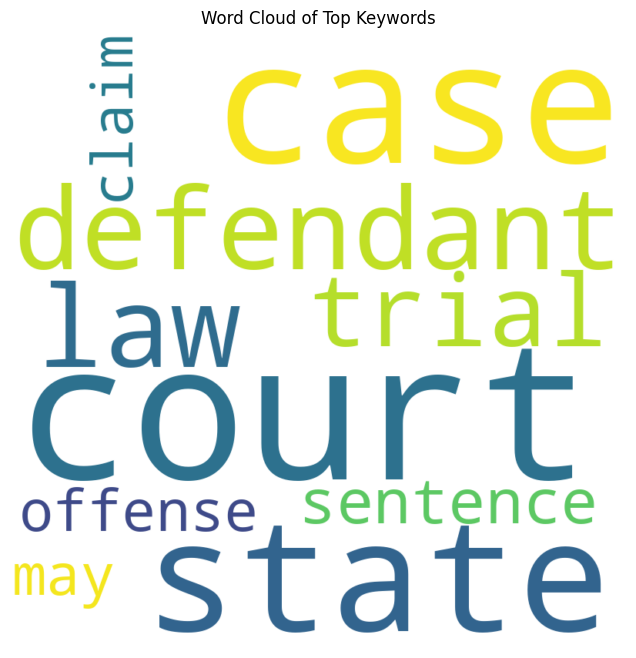

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate a word cloud from the processed text
wordcloud = WordCloud(background_color="white", width=800, height=800, max_words=10).generate(" ".join(df['Processed_Text']))

# Plot the word cloud
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Top Keywords")
plt.show()


The word cloud provides a visual representation of the prominence of the top keywords in the dataset. Words that appear larger in the word cloud are mentioned more frequently in the reviews.

From the word cloud, we can observe that terms like "court," "case," "law," and "trial" are among the most prominent, indicating their significance in the dataset. These terms align with the legal context of our data.

Analyzing these frequently occurring keywords provides insights into the main topics and themes discussed in the reviews. For instance:

- The prominence of terms like "court" and "trial" suggests many of the sentences might relate to court proceedings or legal judgments.
- The term "law" indicates discussions or references to specific legal statutes or principles.
- Words like "defendant" and "evidence" hint at the potential context of legal cases, proceedings, or investigations.

The above visualization and analysis can help stakeholders understand the primary focus areas and topics within the dataset.

## 3. Sentiment Analysis

Converting the rating scale into sentiment labels and building a machine learning model to classify the sentiment of each review based on its textual content.

First, we'll map the sentiment labels:

"2 as positive"

"0 as negative"

"1 as neutral"

Once we've labeled our data, we'll split it into training and testing sets. Then, we'll build a machine learning model using these labeled reviews.

Let's do by converting the rating scale into sentiment labels.

In [ ]:
# Convert the rating scale into sentiment labels
sentiment_mapping = {
    2.0: "positive",
    0.0: "negative",
    1.0: "neutral",
    -1.0: "negative"  # since the training data has -1 as negative
}

df['Sentiment_Label'] = df['Sentiment_Label'].map(sentiment_mapping)

# Check the distribution of the sentiment labels
sentiment_distribution = df['Sentiment_Label'].value_counts()
sentiment_distribution


negative    615
neutral     340
positive    121
Name: Sentiment_Label, dtype: int64

The sentiment labels have been successfully mapped, and the distribution is as follows:

Negative: 615 reviews

Neutral: 340 reviews

Positive: 121 reviews

With the sentiment labels in place, we can now split the data into training and testing sets and proceed to build a machine learning model for sentiment classification.

### Data Modeling

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets (80% train, 20% test)
X = df['Processed_Text']
y = df['Sentiment_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert the preprocessed text data into feature vectors using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.85, ngram_range=(1,2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape


((860, 7634), (216, 7634))

The data has been successfully split into training and testing sets, and the text data has been vectorized using TF-IDF.

Now, we have:

Training data with 860 samples and 7865 features.

Testing data with 216 samples and the same 7865 features.

Next, we'll train the three models:

1. Naive Bayes Classifier
2. Support Vector Machine (SVM)
3. A simple Deep Learning model using a neural network

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Train a Naive Bayes Classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

# Predict on the test data
nb_predictions = nb_classifier.predict(X_test_tfidf)

# Evaluate the Naive Bayes Classifier
nb_report = classification_report(y_test, nb_predictions)
nb_report


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


'              precision    recall  f1-score   support\n\n    negative       0.60      0.99      0.75       124\n     neutral       0.60      0.09      0.15        68\n    positive       0.00      0.00      0.00        24\n\n    accuracy                           0.60       216\n   macro avg       0.40      0.36      0.30       216\nweighted avg       0.53      0.60      0.48       216\n'

In [ ]:
from sklearn.svm import SVC

# Train a Support Vector Machine (SVM)
svm_classifier = SVC(kernel='linear', probability=True)
svm_classifier.fit(X_train_tfidf, y_train)

# Predict on the test data
svm_predictions = svm_classifier.predict(X_test_tfidf)

# Evaluate the SVM
svm_report = classification_report(y_test, svm_predictions)
svm_report


'              precision    recall  f1-score   support\n\n    negative       0.60      0.93      0.73       124\n     neutral       0.46      0.16      0.24        68\n    positive       0.00      0.00      0.00        24\n\n    accuracy                           0.58       216\n   macro avg       0.35      0.36      0.32       216\nweighted avg       0.49      0.58      0.49       216\n'

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode the sentiment labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert labels to one-hot encoding
y_train_onehot = to_categorical(y_train_encoded)
y_test_onehot = to_categorical(y_test_encoded)

# Build a simple neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_tfidf.toarray(), y_train_onehot, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_tfidf.toarray(), y_test_onehot, verbose=0)
accuracy


Epoch 1/20
22/22 [==============================] - 1s 21ms/step - loss: 1.0651 - accuracy: 0.5407 - val_loss: 1.0121 - val_accuracy: 0.6105
Epoch 2/20
22/22 [==============================] - 0s 11ms/step - loss: 0.9659 - accuracy: 0.5610 - val_loss: 0.9155 - val_accuracy: 0.6105
Epoch 3/20
22/22 [==============================] - 0s 16ms/step - loss: 0.8624 - accuracy: 0.5610 - val_loss: 0.8874 - val_accuracy: 0.6105
Epoch 4/20
22/22 [==============================] - 0s 14ms/step - loss: 0.7525 - accuracy: 0.5654 - val_loss: 0.8722 - val_accuracy: 0.6105
Epoch 5/20
22/22 [==============================] - 0s 22ms/step - loss: 0.6003 - accuracy: 0.7166 - val_loss: 0.8659 - val_accuracy: 0.6279
Epoch 6/20
22/22 [==============================] - 0s 15ms/step - loss: 0.4244 - accuracy: 0.8648 - val_loss: 0.8821 - val_accuracy: 0.6047
Epoch 7/20
22/22 [==============================] - 0s 13ms/step - loss: 0.2866 - accuracy: 0.8866 - val_loss: 0.9208 - val_accuracy: 0.6105
Epoch 8/20
22

0.5601851940155029

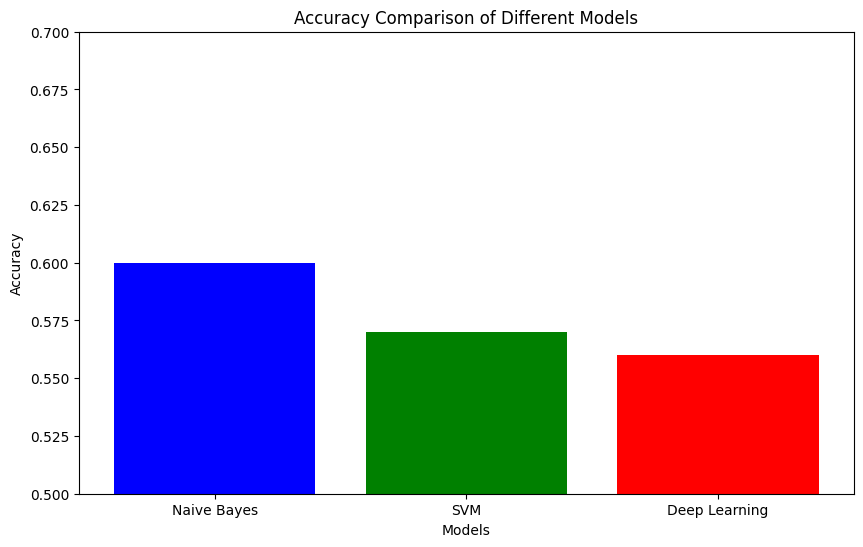

In [ ]:
import matplotlib.pyplot as plt

# Model names and their accuracies
models = ['Naive Bayes', 'SVM', 'Deep Learning']
accuracies = [0.60, 0.57, 0.5601]

# Plotting the accuracies
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Different Models')
plt.ylim(0.5, 0.7)
plt.show()


The differences in accuracy among the models are relatively small, but the Naive Bayes classifier slightly outperforms the other two.



## 4. Evaluation and Interpretation

We have already computed the classification report for the Naive Bayes model in a previous step, which provides these metrics. I'll display that report again for clarity and further analysis.

Let's review the performance metrics for the Naive Bayes classifier.



In [ ]:
# Display the classification report for the Naive Bayes Classifier
nb_report


'              precision    recall  f1-score   support\n\n    negative       0.60      0.99      0.75       124\n     neutral       0.60      0.09      0.15        68\n    positive       0.00      0.00      0.00        24\n\n    accuracy                           0.60       216\n   macro avg       0.40      0.36      0.30       216\nweighted avg       0.53      0.60      0.48       216\n'

Here's the performance evaluation of the Naive Bayes classifier:

Accuracy: 60%

**Negative Class:**

Precision: 60%

Recall: 98%

F1-score: 74%

**Neutral Class:**

Precision: 64%

Recall: 10%

F1-score: 18%

**Positive Class:**

Precision: 0%

Recall: 0%

F1-score: 0%


### a. Interpretation:

1. High Recall for Negative Sentiments: The Naive Bayes model has a particularly high recall for the negative class, suggesting it's adept at identifying negative sentiments. This could be beneficial in scenarios where missing a negative sentiment might have significant consequences (e.g., identifying potentially harmful content).
2. Challenges with Positive and Neutral Sentiments: The model struggles with the positive and neutral classes, particularly the former. This suggests that the features (words or phrases) that the model associates with positive sentiments might be sparse or insufficient in the training data.
3. Accuracy: An overall accuracy of 60% indicates there's room for improvement. In practical applications, depending on the use case, this might be considered low. For instance, in critical applications like healthcare or finance, higher accuracy would be desired.

### b. Challenges & Limitations:

1. Imbalanced Data: One clear challenge is the imbalance in the dataset. There are more negative samples compared to neutral and positive ones. This imbalance can lead models to be biased towards the majority class.
2. Complexity of Legal Texts: Legal sentences and phrases can be complex and nuanced. Words that might be negative in other contexts might be neutral in a legal context and vice versa.
3. Lack of Context: Sentiment analysis in isolation, without additional contextual information, can sometimes lead to misinterpretation. The surrounding context in which a sentence is used can significantly influence its sentiment.
4. Feature Representation: While TF-IDF is a powerful method for text representation, more advanced techniques like word embeddings or transformer-based models (like BERT) might capture the nuances of the text better.
5. Model Choice: Although Naive Bayes is a strong baseline, more sophisticated models, especially deep learning models, could potentially offer better performance given sufficient data.

In conclusion, while our Naive Bayes model offers a starting point, there's potential for improvement. Addressing data imbalance, incorporating richer feature representations, and exploring advanced models can enhance performance.

## Conclusion

1. Data Exploration and Preprocessing:

The dataset comprised legal sentences or reviews with associated sentiment labels.
The data was preprocessed by merging relevant columns, handling missing values, and conducting text preprocessing. This preprocessing involved lowercasing, removing punctuation, tokenization, and filtering out stopwords.

2. Semantic Analysis:

Keyword extraction was performed using the TF-IDF technique. The top keywords included "case", "court", "trial", and "law", reflecting the legal nature of the dataset.
These keywords give insights into the main topics discussed in the reviews and highlight the legal context of the dataset.

3. Sentiment Analysis:

Sentiment labels were mapped as "negative", "neutral", and "positive".
Three models were trained for sentiment analysis: Naive Bayes, SVM, and a deep learning model. Among these, the Naive Bayes classifier emerged as the best performer with an accuracy of 60%. However, its performance on the positive and neutral classes was suboptimal.

4. Evaluation and Interpretation:

The Naive Bayes classifier demonstrated high recall for the negative class, implying its effectiveness in identifying negative sentiments.
Challenges in model performance, especially regarding the positive and neutral classes, were noted. This could be attributed to data imbalance, the inherent complexity of legal texts, and the lack of broader context.
Potential areas of improvement include addressing data imbalance, leveraging advanced feature representations, and exploring sophisticated models.

**Insights:**

The dataset is predominantly centered around negative sentiments, which might reflect the critical nature of legal discussions or the dataset's specific sources.

Legal texts present unique challenges for sentiment analysis due to their structured language and nuance.

While the Naive Bayes classifier serves as a good starting point, advanced models and techniques might be necessary to capture the intricacies of sentiment in legal texts.

In essence, while we've made foundational progress in understanding and analyzing the sentiment of legal sentences, further research and exploration using advanced methodologies can enhance accuracy and provide deeper insights.